# Instrumental variables example using synthetic data - effect of education on profitability
Interested in causal relation between years of education and business profitability, but there are confounders. Say just one confounder 'motivation', which affects both years of education and profitability.
$$
\begin{aligned}
M \sim \mathcal{N}(\mu=0, \sigma=1) \\
D \sim \mathcal{N}(\mu=\mu_D, \sigma=\sigma_D) \\
E = \beta_{E0} + \beta_{E1} M + \beta_{E2} D + \eta \\
P = \beta_{P0} + \beta_{P1} M + \beta_{P2}E + \epsilon \\
\eta \sim \mathcal{N}(\mu=0, \sigma=\sigma_\eta) \\
\epsilon \sim \mathcal{N}(\mu=0, \sigma=\sigma_\epsilon)
\end{aligned}
$$

Where $M$ is motivation, $E$ is years of education, $P$ is business profitability.
Or, as a path diagram:

```mermaid
flowchart LR

dtc[Distance to provider]
mot[Motivation]
yoe[Years of education]
profit[Profitability]
r((Residual))

dtc --> yoe
mot --> yoe
yoe --> profit
mot --> r --> profit
```

In real life ability would be unobserved, and we would consider our model to be
$$
W = r + \beta_{P2} E
$$
But the residual $r$ is correlated with experience $E$, so OLS would give a biased estimate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

rng = np.random.default_rng(seed=2222)
N = 1000

In [88]:
eta = rng.normal(scale=2, size=N)
epsilon = rng.normal(scale=1000, size=N)
M = rng.standard_normal(N)
D = rng.normal(loc=100, scale=20, size=N)
beta_E0 = -2
beta_E1 = 2
beta_E2 = 0.1
beta_P0 = 200
beta_P1 = 1000
beta_P2 = 500
E = beta_E0 + beta_E1*M + beta_E2*D + eta
P = beta_P0 + beta_P1*M + beta_P2*E + epsilon

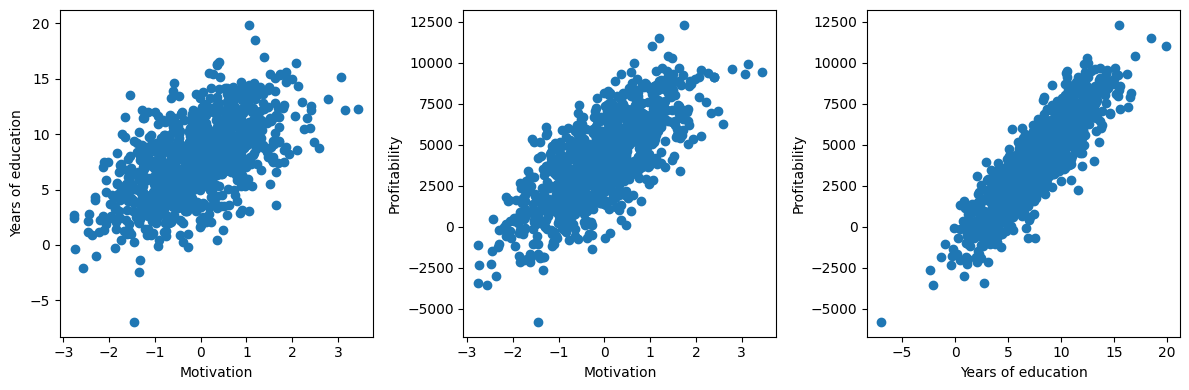

In [89]:
fig,ax = plt.subplots(1,3, figsize=[12,4])
ax[0].plot(M, E, 'o')
ax[0].set_xlabel("Motivation")
ax[0].set_ylabel("Years of education")

ax[1].plot(M, P, 'o')
ax[1].set_xlabel("Motivation")
ax[1].set_ylabel("Profitability")

ax[2].plot(E, P, 'o')
ax[2].set_xlabel("Years of education")
ax[2].set_ylabel("Profitability")

plt.tight_layout()
plt.savefig("scatter-naive-regression.png")

In [90]:
# Naive OLS gives a biased estimate.
# True value of $\beta_{P2}$ is 500, but that's not even in our confidence interval. We're overestimating the effect.
ols_y = P
ols_x = sm.add_constant(E)
model = sm.OLS(ols_y, ols_x)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     3382.
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        22:49:30   Log-Likelihood:                -8561.3
No. Observations:                1000   AIC:                         1.713e+04
Df Residuals:                     998   BIC:                         1.714e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1182.6896     97.242    -12.162      0.000   -1373.511    -991.868
x1           668.1038     11.488     58.158      0.000     645.561     690.647
==============================================================================
Omnibus:                        0.858   Durbin-Watson:                   2.056
Prob(Omnibus):                  0.651   Jarque-Bera (JB):                0.731
Skew:                          -0.009   Prob(JB):                        0.694
Kurtosis:                       3.131   Cond. No.                         20.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Introducing instrumental variables
Distance to college has a causal effect on how much education you get. But it's not necessarily related to ability. 

**Relevance assumption**: The instrument (distance to college) has a causal effect on the treatment.

**Exogeneity assumption**: The instrument is randomly assigned to units - it's unrelated to the residual.

**Exclusion restriction**: The instrument does not have a direct causal effect on the outcome.

This latter is debatable - proximity to college may mean a higher chance of being raised by a highly skilled academic, which could affect motivation. Put this aside for now.

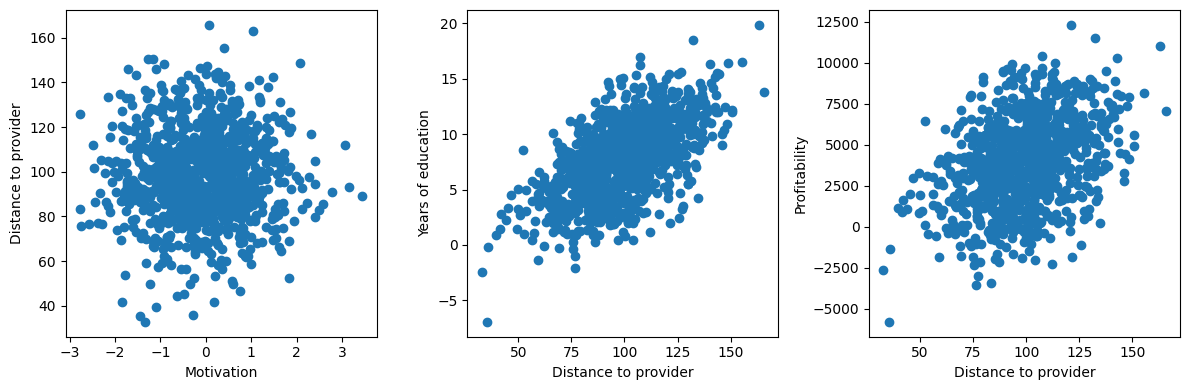

In [95]:
fig,ax = plt.subplots(1,3, figsize=[12,4])
ax[0].plot(M, D, 'o')
ax[0].set_xlabel("Motivation")
ax[0].set_ylabel("Distance to provider")

ax[2].plot(D, P, 'o')
ax[2].set_xlabel("Distance to provider")
ax[2].set_ylabel("Profitability")

ax[1].plot(D, E, 'o')
ax[1].set_xlabel("Distance to provider")
ax[1].set_ylabel("Years of education")

plt.tight_layout()

plt.savefig("scatter-instrumental-variable.png")

# Estimating the causal effect with 2SLS

In [96]:
model1 = sm.OLS(E, sm.add_constant(D))
result1 = model1.fit()
E_hat = result1.predict()
model2 = sm.OLS(P, sm.add_constant(E_hat))
result2 = model2.fit()
result2.summary()
# Point estimate only, standard errors are off because we aren't accounting for the variance in our estimates from the first stage of LS.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     192.7
Date:                Fri, 15 May 2026   Prob (F-statistic):           3.50e-40
Time:                        23:11:21   Log-Likelihood:                -9212.6
No. Observations:                1000   AIC:                         1.843e+04
Df Residuals:                     998   BIC:                         1.844e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.9888    296.938     -0.034      0.973    -592.683     572.705
x1           516.0922     37.182     13.880      0.000     443.129     589.056
==============================================================================
Omnibus:                        1.162   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.559   Jarque-Bera (JB):                1.235
Skew:                          -0.058   Prob(JB):                        0.539
Kurtosis:                       2.874   Cond. No.                         31.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [93]:
# Using built in library, gives correct standard errors and confidence intervals.
from statsmodels.sandbox.regression.gmm import IV2SLS
model_2sls = IV2SLS(P, sm.add_constant(E), instrument=sm.add_constant(D))
result_2sls = model_2sls.fit()
result_2sls.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          IV2SLS Regression Results                           
==============================================================================
Dep. Variable:                      y   R-squared:                       0.732
Model:                         IV2SLS   Adj. R-squared:                  0.732
Method:                     Two Stage   F-statistic:                     603.0
                        Least Squares   Prob (F-statistic):          1.55e-104
Date:                Fri, 15 May 2026                                         
Time:                        22:49:39                                         
No. Observations:                1000                                         
Df Residuals:                     998                                         
Df Model:                           1                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.9888    167.844     -0.060      0.953    -339.356     319.378
x1           516.0922     21.017     24.556      0.000     474.850     557.335
==============================================================================
Omnibus:                        0.597   Durbin-Watson:                   2.061
Prob(Omnibus):                  0.742   Jarque-Bera (JB):                0.470
Skew:                           0.003   Prob(JB):                        0.791
Kurtosis:                       3.106   Cond. No.                         20.8
==============================================================================
"""

In [125]:
# For my own interest, what happens if we could measure motivation and control for it?
X = sm.add_constant(np.vstack((E,M)).T)
model_complete = sm.OLS(P, X)
results_complete = model_complete.fit()
results_complete.summary()
# Similar estimate, but standard errors are much narrower! Better power etc.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     2926.
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        23:18:56   Log-Likelihood:                -8337.4
No. Observations:                1000   AIC:                         1.668e+04
Df Residuals:                     997   BIC:                         1.670e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        101.8955     94.750      1.075      0.282     -84.036     287.827
x1           512.7319     11.281     45.451      0.000     490.595     534.869
x2           958.1358     40.369     23.734      0.000     878.917    1037.354
==============================================================================
Omnibus:                        1.120   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.571   Jarque-Bera (JB):                1.010
Skew:                           0.004   Prob(JB):                        0.604
Kurtosis:                       3.155   Cond. No.                         26.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Plotting regression lines

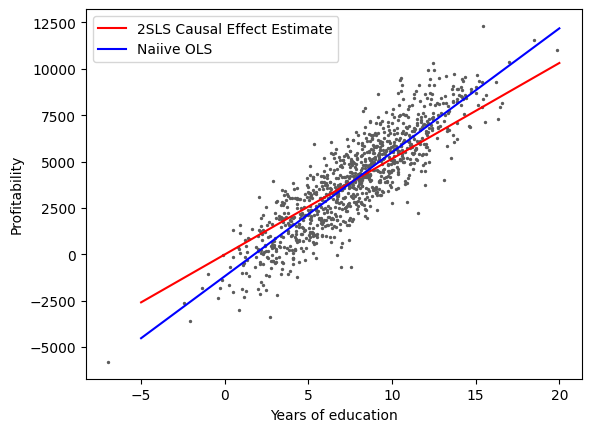

In [94]:
plt.figure()
plt.xlabel("Years of education")
plt.ylabel("Profitability")

yoe = sm.add_constant(np.linspace(-5, 20))
y_2sls_pred = result_2sls.predict(yoe)
y_naive_pred = results.predict(yoe)

plt.scatter(E, P, c=np.array(['#5c5c5c']), s=2)
plt.plot(yoe[:,1], y_2sls_pred, 'r-', label="2SLS Causal Effect Estimate")
plt.plot(yoe[:,1], y_naive_pred, 'b-', label="Naiive OLS")
plt.legend()
plt.savefig("regression-comparison.png")